# `MultiCropWrapper` 의 해상도 그룹핑 한 줄 뜯어보기

DINO 는 한 이미지에서 crop 을 10개 뽑는다 — global 2개(224) + local 8개(96).
이걸 그냥 하나씩 backbone 에 넣으면 forward 가 **10회**다.
그런데 `MultiCropWrapper.forward` 는 딱 한 줄로 **같은 해상도끼리 묶어** forward 를 **2회**로 줄인다.

```python
idx_crops = torch.cumsum(torch.unique_consecutive(
    torch.tensor([inp.shape[-1] for inp in x]), return_counts=True)[1], 0)
```

이 노트북은 이 한 줄을 세 조각으로 쪼개 각각 출력해 보고,
실제 `MultiCropWrapper` 에 "호출을 세는 backbone" 을 꽂아 forward 횟수를 실측한다.

핵심 결론 먼저:

$$
\texttt{[224,224,96,96,96,96,96,96,96,96]}
\;\xrightarrow{\text{unique\_consecutive}}\;
\text{counts}=[2,8]
\;\xrightarrow{\text{cumsum}}\;
[2,\,10]
$$

`[2, 10]` 은 **경계 인덱스**다. 슬라이스 `x[0:2]`, `x[2:10]` 두 덩어리가 된다.

In [1]:
# 필요 패키지: torch>=2.0, plotly>=6, kaleido, (선택) numpy
import os
import sys

import torch
import torch.nn as nn

# 실제 DINO 구현체를 그대로 쓴다
sys.path.insert(0, "/home/sungwoo/projects/swcho/dino")
from utils import MultiCropWrapper  # noqa: E402


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 대화형 환경
    HERE = os.getcwd()

torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.4.0+cu121


## 1단계 — 해상도 리스트 만들기

`x` 는 crop 텐서들의 **리스트**다. 각 원소는 $(B, 3, H, W)$.
코드가 보는 것은 `inp.shape[-1]`, 즉 마지막 축 = **너비 $W$** 하나뿐이다.
(DINO crop 은 정사각이라 $W$ 만으로 해상도를 식별할 수 있다.)

In [2]:
B = 4  # 배치 크기
SORTED_RES = [224, 224] + [96] * 8            # DINO 가 실제로 넘기는 순서
SHUFFLED_RES = [224, 96, 96, 96, 96, 224, 96, 96, 96, 96]  # 일부러 섞은 순서


def make_crops(res_list, b=B):
    """해상도 리스트 -> (B,3,r,r) 텐서들의 리스트."""
    return [torch.randn(b, 3, r, r) for r in res_list]


x_sorted = make_crops(SORTED_RES)
res = torch.tensor([inp.shape[-1] for inp in x_sorted])
print("crop 개수        :", len(x_sorted))
print("각 crop shape[0] :", tuple(x_sorted[0].shape), tuple(x_sorted[-1].shape))
print("해상도 리스트     :", res.tolist())

crop 개수        : 10
각 crop shape[0] : (4, 3, 224, 224) (4, 3, 96, 96)
해상도 리스트     : [224, 224, 96, 96, 96, 96, 96, 96, 96, 96]


## 2단계 — `torch.unique_consecutive(..., return_counts=True)`

이름 그대로 **연속으로 같은 값**만 하나로 접는다 (Unix `uniq` 와 같다).
반환은 튜플 `(values, counts)` — 코드가 쓰는 건 `[1]` 인덱스, 즉 **counts** 뿐이다.

$$
[224,224,\underbrace{96,\dots,96}_{8}] \;\longmapsto\; \text{values}=[224,96],\ \text{counts}=[2,8]
$$

In [3]:
uc = torch.unique_consecutive(res, return_counts=True)
values, counts = uc
print("반환 튜플 길이 :", len(uc))
print("[0] values    :", values.tolist(), "  <- 코드에서 안 쓴다")
print("[1] counts    :", counts.tolist(), "  <- 이것만 쓴다")

반환 튜플 길이 : 2
[0] values    : [224, 96]   <- 코드에서 안 쓴다
[1] counts    : [2, 8]   <- 이것만 쓴다


## 3단계 — `torch.cumsum(counts, 0)` → 경계 인덱스

counts 는 "각 그룹의 크기"지 "어디서 끊는지"가 아니다.
누적합을 취하면 그대로 **슬라이스의 끝 인덱스**가 된다.

$$
\text{counts}=[2,8] \;\xrightarrow{\ \text{cumsum}\ }\; [2,\,2{+}8] = [2,\,10]
$$

In [4]:
idx_crops = torch.cumsum(counts, 0)
print("counts    :", counts.tolist())
print("idx_crops :", idx_crops.tolist(), "  <- 각 그룹의 end index")

# 원래 한 줄과 동일한지 확인
one_liner = torch.cumsum(torch.unique_consecutive(
    torch.tensor([inp.shape[-1] for inp in x_sorted]),
    return_counts=True,
)[1], 0)
print("한 줄 버전 :", one_liner.tolist(), " 동일?", torch.equal(idx_crops, one_liner))

counts    : [2, 8]
idx_crops : [2, 10]   <- 각 그룹의 end index
한 줄 버전 : [2, 10]  동일? True


## 4단계 — `start_idx, end_idx` 루프가 만드는 슬라이스

```python
start_idx, output = 0, torch.empty(0).to(x[0].device)
for end_idx in idx_crops:
    _out = self.backbone(torch.cat(x[start_idx: end_idx]))
    output = torch.cat((output, _out))
    start_idx = end_idx
```

`start_idx` 를 직전 `end_idx` 로 밀어 주는 게 전부다.
`torch.cat` 은 리스트 안 텐서들을 **배치 축으로 이어 붙인다** — 그래서 한 그룹이 한 번의 forward 로 끝난다.

In [5]:
def simulate_loop(res_list, b=B, label=""):
    """실제 forward 루프의 슬라이싱만 재현해서 (start, end, shape) 를 뽑는다."""
    xs = [torch.empty(b, 3, r, r) for r in res_list]
    idx = torch.cumsum(torch.unique_consecutive(
        torch.tensor([i.shape[-1] for i in xs]), return_counts=True)[1], 0)
    spans, start_idx = [], 0
    for end_idx in idx:
        chunk = torch.cat(xs[start_idx:end_idx])
        spans.append((int(start_idx), int(end_idx), tuple(chunk.shape)))
        start_idx = end_idx
    if label:
        print(f"[{label}] idx_crops = {idx.tolist()}  -> backbone forward {len(spans)}회")
        for k, (s, e, sh) in enumerate(spans):
            print(f"   call#{k}: x[{s}:{e}]  ({e - s}개 crop) -> torch.cat -> {sh}")
    return spans


spans_sorted = simulate_loop(SORTED_RES, label="정렬됨")

[정렬됨] idx_crops = [2, 10]  -> backbone forward 2회
   call#0: x[0:2]  (2개 crop) -> torch.cat -> (8, 3, 224, 224)
   call#1: x[2:10]  (8개 crop) -> torch.cat -> (32, 3, 96, 96)


## 순서를 섞으면? — `unique_consecutive` 는 정렬하지 않는다

이게 이 설계의 **암묵적 계약**이다: crop 리스트는 해상도별로 **연속**해 있어야 한다.
섞여 있어도 `torch.cat` 은 같은 해상도끼리만 묶이므로 **에러는 나지 않는다**.
대신 그룹이 잘게 쪼개져 forward 횟수만 조용히 늘어난다.

In [6]:
spans_shuffled = simulate_loop(SHUFFLED_RES, label="섞임")
print()
print("정렬됨 해상도 :", SORTED_RES)
print("섞임   해상도 :", SHUFFLED_RES)
print(f"forward 횟수  : {len(spans_sorted)}회  vs  {len(spans_shuffled)}회")

[섞임] idx_crops = [1, 5, 6, 10]  -> backbone forward 4회
   call#0: x[0:1]  (1개 crop) -> torch.cat -> (4, 3, 224, 224)
   call#1: x[1:5]  (4개 crop) -> torch.cat -> (16, 3, 96, 96)
   call#2: x[5:6]  (1개 crop) -> torch.cat -> (4, 3, 224, 224)
   call#3: x[6:10]  (4개 crop) -> torch.cat -> (16, 3, 96, 96)

정렬됨 해상도 : [224, 224, 96, 96, 96, 96, 96, 96, 96, 96]
섞임   해상도 : [224, 96, 96, 96, 96, 224, 96, 96, 96, 96]
forward 횟수  : 2회  vs  4회


### `torch.unique` (비연속) 와의 대비

그냥 `torch.unique` 를 쓰면 값을 **정렬**해 버려서 원래 위치 정보가 사라진다.
cumsum 을 해도 "리스트의 어디를 잘라야 하는지"와 아무 관계가 없는 숫자가 나온다.

In [7]:
for name, r in [("정렬됨", SORTED_RES), ("섞임", SHUFFLED_RES)]:
    t = torch.tensor(r)
    uc_v, uc_c = torch.unique_consecutive(t, return_counts=True)
    u_v, u_c = torch.unique(t, return_counts=True)
    print(f"[{name}]")
    print(f"  unique_consecutive : values={uc_v.tolist()} counts={uc_c.tolist()} "
          f"cumsum={torch.cumsum(uc_c, 0).tolist()}  <- 올바른 경계")
    print(f"  unique             : values={u_v.tolist()} counts={u_c.tolist()} "
          f"cumsum={torch.cumsum(u_c, 0).tolist()}  <- 순서 뒤섞임, 경계 아님")

[정렬됨]
  unique_consecutive : values=[224, 96] counts=[2, 8] cumsum=[2, 10]  <- 올바른 경계
  unique             : values=[96, 224] counts=[8, 2] cumsum=[8, 10]  <- 순서 뒤섞임, 경계 아님
[섞임]
  unique_consecutive : values=[224, 96, 224, 96] counts=[1, 4, 1, 4] cumsum=[1, 5, 6, 10]  <- 올바른 경계
  unique             : values=[96, 224] counts=[8, 2] cumsum=[8, 10]  <- 순서 뒤섞임, 경계 아님


## 실측 — 카운팅 backbone 을 진짜 `MultiCropWrapper` 에 꽂기

`MultiCropWrapper.__init__` 은 `backbone.fc`, `backbone.head` 를 `nn.Identity()` 로
**덮어쓴다**(ImageNet 분류 레이어 제거). 그래서 대역 backbone 도 두 속성을 갖고 있어야 한다.

이 backbone 은 호출마다 입력 shape 을 기록하고,
출력 벡터의 **첫 성분에 입력 해상도를 새겨 넣는다** — 나중에 출력 행 순서를 검증하는 데 쓴다.

In [8]:
D = 8  # 가짜 feature 차원


class CountingBackbone(nn.Module):
    """호출 횟수와 입력 shape 을 기록하는 backbone. 출력에 입력 해상도를 새긴다."""

    def __init__(self, dim=D):
        super().__init__()
        self.dim = dim
        self.fc = nn.Identity()     # MultiCropWrapper 가 덮어쓴다
        self.head = nn.Identity()   # MultiCropWrapper 가 덮어쓴다
        self.calls = []             # [(n, C, H, W), ...]

    def forward(self, x):
        self.calls.append(tuple(x.shape))
        n = x.shape[0]
        out = torch.zeros(n, self.dim)
        out[:, 0] = float(x.shape[-1])          # 입력 해상도를 0번 성분에 각인
        out[:, 1] = torch.arange(n, dtype=torch.float)  # 그룹 내 위치
        return out


def run_wrapper(res_list, b=B):
    bb = CountingBackbone()
    model = MultiCropWrapper(bb, nn.Identity())   # head 는 항등으로 두고 특징을 그대로 본다
    with torch.no_grad():
        out = model(make_crops(res_list, b))
    return bb.calls, out


calls_sorted, out_sorted = run_wrapper(SORTED_RES)
calls_shuffled, out_shuffled = run_wrapper(SHUFFLED_RES)

print(f"[정렬됨] backbone forward {len(calls_sorted)}회")
for i, c in enumerate(calls_sorted):
    print(f"    call#{i}: {c}")
print(f"    출력 shape: {tuple(out_sorted.shape)}   # (2+8) x B={B} = 40 행")
print()
print(f"[섞임 ] backbone forward {len(calls_shuffled)}회")
for i, c in enumerate(calls_shuffled):
    print(f"    call#{i}: {c}")
print(f"    출력 shape: {tuple(out_shuffled.shape)}   # 행 수는 동일, 호출만 늘었다")

[정렬됨] backbone forward 2회
    call#0: (8, 3, 224, 224)
    call#1: (32, 3, 96, 96)
    출력 shape: (40, 8)   # (2+8) x B=4 = 40 행

[섞임 ] backbone forward 4회
    call#0: (4, 3, 224, 224)
    call#1: (16, 3, 96, 96)
    call#2: (4, 3, 224, 224)
    call#3: (16, 3, 96, 96)
    출력 shape: (40, 8)   # 행 수는 동일, 호출만 늘었다


## 출력 행 순서는 입력 crop 순서와 같은가?

그룹핑은 **성능 최적화일 뿐** 의미를 바꾸면 안 된다.
출력 0번 성분에 각인해 둔 해상도를 읽어, `[res]*B` 를 순서대로 이어 붙인 것과 같은지 확인한다.

$$
\text{row order} = \underbrace{[r_0]\times B}_{\text{crop }0},\ \underbrace{[r_1]\times B}_{\text{crop }1},\ \dots
$$

In [9]:
for name, res_list, out in [("정렬됨", SORTED_RES, out_sorted),
                            ("섞임", SHUFFLED_RES, out_shuffled)]:
    got = out[:, 0].int().tolist()
    want = [r for r in res_list for _ in range(B)]
    print(f"[{name}] 출력 행의 해상도 각인")
    print(f"   실제 : {got}")
    print(f"   기대 : {want}")
    print(f"   일치 : {got == want}")

[정렬됨] 출력 행의 해상도 각인
   실제 : [224, 224, 224, 224, 224, 224, 224, 224, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96]
   기대 : [224, 224, 224, 224, 224, 224, 224, 224, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96]
   일치 : True
[섞임] 출력 행의 해상도 각인
   실제 : [224, 224, 224, 224, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 224, 224, 224, 224, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96]
   기대 : [224, 224, 224, 224, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 224, 224, 224, 224, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96]
   일치 : True


두 경우 모두 **행 순서 = 입력 crop 순서**다.
즉 섞인 리스트도 결과는 정확하고, 손해는 오직 forward 횟수(=속도)뿐이다.
조용히 느려지기 때문에 알아채기 어렵다 — 그래서 "crop 은 해상도 내림차순" 이 계약이다.

## 시각화 — 각 backbone 호출이 덮는 crop 구간 (간트)

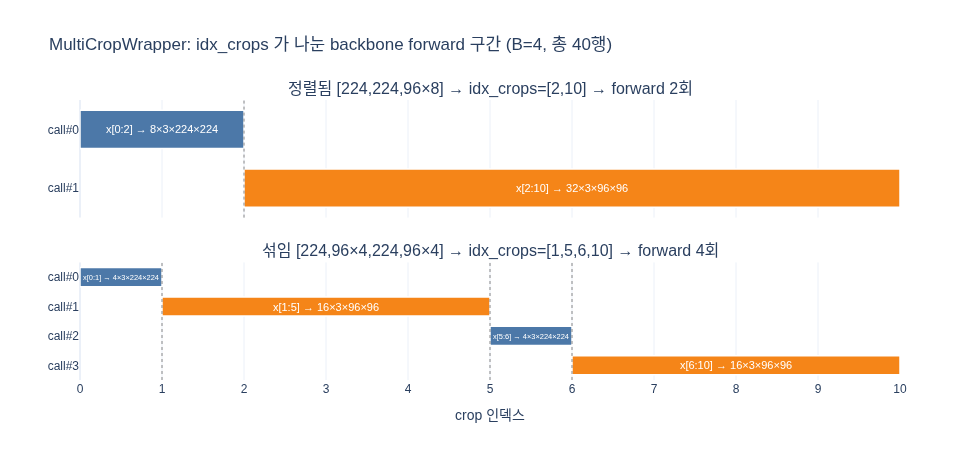

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/1e4b7aca-d527-4072-98eb-c0b3841c081e/expy.png


In [10]:
import plotly.graph_objects as go  # noqa: E402
from plotly.subplots import make_subplots  # noqa: E402

COLOR = {224: "#4C78A8", 96: "#F58518"}

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.16,
    subplot_titles=(
        f"정렬됨 [224,224,96×8] → idx_crops=[2,10] → forward {len(calls_sorted)}회",
        f"섞임 [224,96×4,224,96×4] → idx_crops=[1,5,6,10] → forward {len(calls_shuffled)}회",
    ),
)

for row, (res_list, spans) in enumerate(
        [(SORTED_RES, spans_sorted), (SHUFFLED_RES, spans_shuffled)], start=1):
    for k, (s, e, sh) in enumerate(spans):
        r = res_list[s]
        fig.add_trace(go.Bar(
            x=[e - s], y=[f"call#{k}"], base=[s], orientation="h",
            marker=dict(color=COLOR[r], line=dict(color="white", width=1.5)),
            text=f"x[{s}:{e}] → {sh[0]}×3×{r}×{r}",
            textposition="inside", insidetextanchor="middle",
            textfont=dict(color="white", size=11),
            showlegend=False,
            hovertemplate=f"call#{k}<br>x[{s}:{e}]<br>해상도 {r}<extra></extra>",
        ), row=row, col=1)
    # 경계선
    for _, e, _ in spans[:-1]:
        fig.add_vline(x=e, line=dict(color="#888", width=1, dash="dot"), row=row, col=1)

fig.update_xaxes(title_text="crop 인덱스", range=[0, 10], dtick=1, row=2, col=1)
fig.update_xaxes(range=[0, 10], dtick=1, row=1, col=1)
fig.update_yaxes(autorange="reversed")
fig.update_layout(
    title="MultiCropWrapper: idx_crops 가 나눈 backbone forward 구간 (B=4, 총 40행)",
    height=460, width=980, bargap=0.35,
    template="plotly_white", font=dict(size=12),
)

_show(fig)

png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

## 정리

| 조각 | 역할 |
|---|---|
| `[inp.shape[-1] for inp in x]` | 각 crop 의 너비 = 해상도 지문 |
| `unique_consecutive(..., return_counts=True)[1]` | **연속** 구간별 개수 `[2,8]` (정렬 안 함) |
| `cumsum(..., 0)` | 개수 → 슬라이스 끝 인덱스 `[2,10]` |
| `for end_idx in idx_crops` + `start_idx` | `x[0:2]`, `x[2:10]` 두 번의 forward |
| `head(output)` (루프 밖) | 모든 crop 특징을 concat 해 head 는 **한 번만** — head 의 BN 통계가 함께 잡힌다 |

- forward 횟수 = **서로 다른 해상도의 연속 런(run) 개수**. 리스트 정렬 여부에 직접 의존한다.
- 순서가 섞여도 **결과는 정확**하고 출력 행 순서도 보존된다. 느려질 뿐이라 조용히 지나간다.